<h3 style="text-align: center;"> <strong> UNIVERSIDAD TECNOLÓGICA DE PANAMÁ </strong></h3>
<h3 style="text-align: center;">FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
<h3 style="text-align: center;">DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
    
<h1 style="text-align: center;"><strong>-------LABORATORIO N°3:  Gráficos con MatPlotLib-------</strong></h1>
<h3 style="text-align: center;">ANÁLISIS DE DATOS Y TOMA DE DECISIONES PARA COMPUTACIÓN - 1195</h3>




|  **FACILITADOR** | Dr. José Carlos Rangel Ortiz          |
|-----------------|---------------------------------------|
| **MÓDULO 1**    | Introducción a la Ciencia de Datos    |
|  **UNIDAD 2**    | Minería de Datos       |
    

| **NOMBRE DEL ESTUDIANTE:** | Jhuomar Boskoll Barría Quintero \| 9-766-196 |
|----------------------------|-----------------------------------------------------------------------------------------|
    

## Introducción al laboratorio

Este laboratorio, se enfoca en mostrar los fundamentos de Matplotlib, una biblioteca de Python para crear visualizaciones de datos. Matplotlib es una herramienta esencial para científicos de datos, analistas de datos e investigadores que trabajan con datos.

**Características principales de Matplotlib**

- **Tipos de gráficos**: Matplotlib te permite crear una amplia variedad de tipos de gráficos, incluyendo:
    - Diagramas de líneas
    - Diagramas de barras
    - Histogramas
    - Gráficos de dispersión
    - Mapas de calor
    - Entre otras
- **Personalización**: Puedes personalizar casi todos los aspectos de tus gráficos, como colores, estilos de línea, tamaño de fuente, etiquetas y leyendas.
- **Interactividad**: Puedes crear gráficos interactivos que permitan a los usuarios explorar los datos y obtener información adicional.
- **Integraciones**: Matplotlib se integra con otras bibliotecas populares de Python como NumPy, Pandas, Scikit-Learn y Seaborn.

Matplotlib se integra a la perfección con otras bibliotecas populares de ciencia de datos como NumPy, Pandas y Scikit-Learn, permitiendo un flujo de trabajo fluido y eficiente. De esta manera, los datos se pueden procesar, analizar y visualizar sin necesidad de cambiar constantemente entre herramientas.

En resumen, Matplotlib es una herramienta esencial en el arsenal del científico de datos. Su poder para transformar datos en información visual, su facilidad de uso y su capacidad para integrarse con otras herramientas lo convierten en un aliado indispensable para descubrir patrones, comunicar hallazgos y tomar decisiones basadas en datos.

En este laboratorio se presentarán distintos retos y fragmentos de código que trabjanado con Pandas nos permitiran generar gráficos interesantes para analizar y resumir la información contenida en un dataset. 

El dataset a utilizar en esta ocasión contiene datos sobre el % de Partos atendidos por personal capacitado en diversos países del mundo, durante un periodo de tiempo. El porcentaje se presenta por país y por año, pero no todos los países tienen información en para todos los años. Este conjunto de datos ha sido recopilado por la Organización Mundial de la Salud entre el 2000-2022.

Infromacion Adicional del Dataset
- https://www.who.int/data/gho/data/indicators/indicator-details/GHO/births-attended-by-skilled-health-personnel-(-)




## Problemas Propuestos
Resuleva cada solicitud en la celda indicada. Utilice solo comandos de **MatPlotLib** para el desarrollo del laboratorio.
Recuerde siempre consultar la documentación de la librería disponible en: https://matplotlib.org/stable/users/index 

## **[1]**  Carge el Dataset *AtencionPartos.csv*

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.parse import urlparse

CSV = "AtencionPartos.csv"


def _descargar_csv_si_falta() -> Path | None:
    """En Colab u otros entornos sin el CSV local: descarga desde el repo en GitHub."""
    import urllib.error
    import urllib.request

    urls = (
        "https://raw.githubusercontent.com/Quantumquirkz/Data-Science---Engineer---Analytics/main/labs/Lab3/AtencionPartos.csv",
        "https://raw.githubusercontent.com/Quantumquirkz/Data-Science---Engineer---Analytics/master/labs/Lab3/AtencionPartos.csv",
    )
    dest_dir = Path("/content") if Path("/content").is_dir() else Path.cwd()
    dest = dest_dir / CSV
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=90) as resp:
                data = resp.read()
            if len(data) < 200:
                continue
            dest.write_bytes(data)
            if dest.is_file():
                return dest_dir.resolve()
        except (urllib.error.URLError, OSError, ValueError, TimeoutError):
            continue
    return None


def _donde_esta_el_csv() -> Path:
    """Carpeta que contiene el CSV: junto al .ipynb solo si el archivo existe ahí (evita rutas fantasma)."""
    raw = globals().get("__vsc_ipynb_file__")
    if raw:
        s = str(raw).strip()
        fs = urlparse(s).path if "://" in s else s
        fs = (fs or "").strip()
        if fs.lower().endswith(".ipynb"):
            carpeta = Path(fs).expanduser().parent
            if (carpeta / CSV).is_file():
                return carpeta.resolve()
    for raiz in (Path.cwd(), Path.cwd() / "labs" / "Lab3"):
        raiz = raiz.resolve()
        if (raiz / CSV).is_file():
            return raiz
    desc = _descargar_csv_si_falta()
    if desc is not None:
        return desc
    raise FileNotFoundError(
        f"No está {CSV} y la descarga desde GitHub falló. cwd={Path.cwd()!s}"
    )


_base = _donde_esta_el_csv()
dfPartos = pd.read_csv(_base / CSV, sep=";")
dfPartos


,Pais,Periodo,PartosAtendidos
0,Afghanistan,2003,14.3
1,Afghanistan,2010,34.3
2,Afghanistan,2015,50.5
3,Afghanistan,2018,58.8
4,Albania,2000,99.1
...,...,...,...
1993,Zambia,2007,45.2
1994,Zimbabwe,2009,60.2
1995,Zimbabwe,2014,80.0
1996,Zimbabwe,2015,78.1


## **[2]**  Indique los tipos de datos de cada columna

In [19]:
dfPartos.dtypes

,0
Pais,object
Periodo,int64
PartosAtendidos,float64


## **[3]**  Indique la cantidad de paises en el dataset 

In [20]:
dfPartos["Pais"].nunique()

186

## **[4]**  Indique la cantidad de datos que se tienen por país, ordene de manera ascendente (consulte la función *sort_values*)

In [21]:
dfPartos.groupby("Pais")["Periodo"].count().sort_values(ascending=True)

,Periodo
Pais,
Algeria,1
Bermuda,1
Gabon,1
Morocco,1
Liberia,1
...,...
Azerbaijan,22
Finland,22
Poland,22


## **[5]**  Indique la cantidad de años disponibles en el dataset

In [22]:
dfPartos["Periodo"].nunique()

23

## **[6]**  Seleccionando Panamá realice un gráfico de barras con los valores disponibles

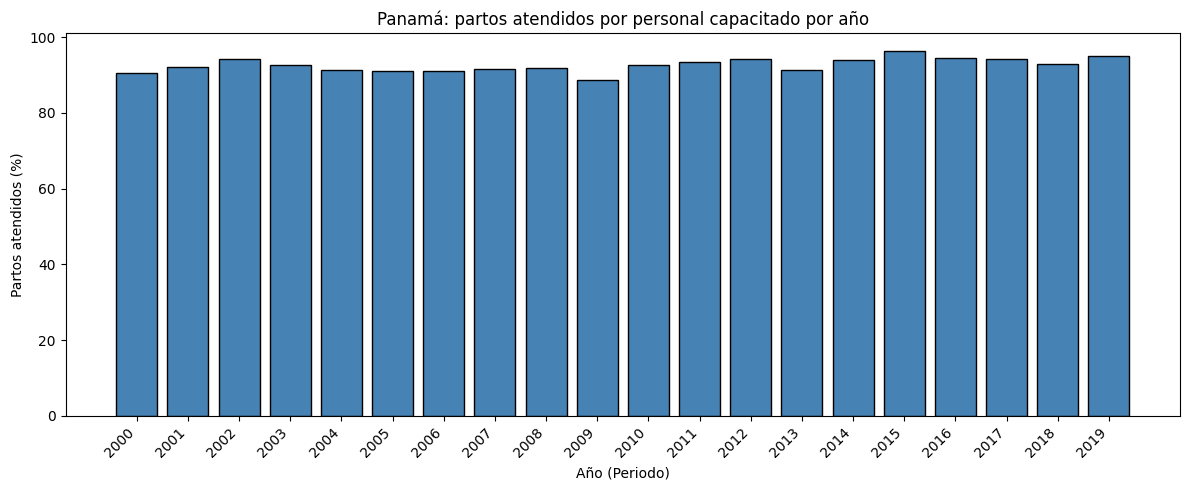

In [23]:
panama = dfPartos[dfPartos["Pais"] == "Panama"]

plt.figure(figsize=(12, 5))
plt.bar(panama["Periodo"].astype(str), panama["PartosAtendidos"], color="steelblue", edgecolor="black")
plt.xlabel("Año (Periodo)")
plt.ylabel("Partos atendidos (%)")
plt.title("Panamá: partos atendidos por personal capacitado por año")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## **[7]**  Indique cual es el la tasa de atención mayor y menor para Panamá

In [24]:
panama = dfPartos[dfPartos["Pais"] == "Panama"]
max_fila = panama.loc[panama["PartosAtendidos"].idxmax()]
min_fila = panama.loc[panama["PartosAtendidos"].idxmin()]

print(f"Mayor tasa: {max_fila['PartosAtendidos']:.1f}% (año {int(max_fila['Periodo'])})")
print(f"Menor tasa: {min_fila['PartosAtendidos']:.1f}% (año {int(min_fila['Periodo'])})")

Mayor tasa: 96.3% (año 2015)
Menor tasa: 88.6% (año 2009)


## **[8]**  Genere un Dataset para Los Países Panama, Romania, Azerbaijan y Brazil

Para seleccionar este segmento del dataset se recomienda usar el metodo *.isin()* disponible en un dataframe de Pandas. Este metedo recibe una lista con los elementos que deseamos seleccionar de nuestro dataset original. El siguiente fragmento presenta una idea de la manera de seleccionar usando este metodo.  Imprima las primeras 5 líneas de este nuevo dataset.

```python
new_df = df[(df['Columna'].isin(["Elemento1", "Elemento2", "Elemento3"]))]
```



In [25]:
paises_sel = ["Panama", "Romania", "Azerbaijan", "Brazil"]
new_df = dfPartos[dfPartos["Pais"].isin(paises_sel)]
new_df.head()

,Pais,Periodo,PartosAtendidos
114,Azerbaijan,2000,80.7
115,Azerbaijan,2001,88.0
116,Azerbaijan,2002,94.0
117,Azerbaijan,2003,95.8
118,Azerbaijan,2004,95.9


## **[9]**  Utilizando la selección anterior, genere mediante subplot un gráfico para cada país usando un mismo lienzo y un subplot por país 
### Rotule adecuadamente los ejes de sus gráficas

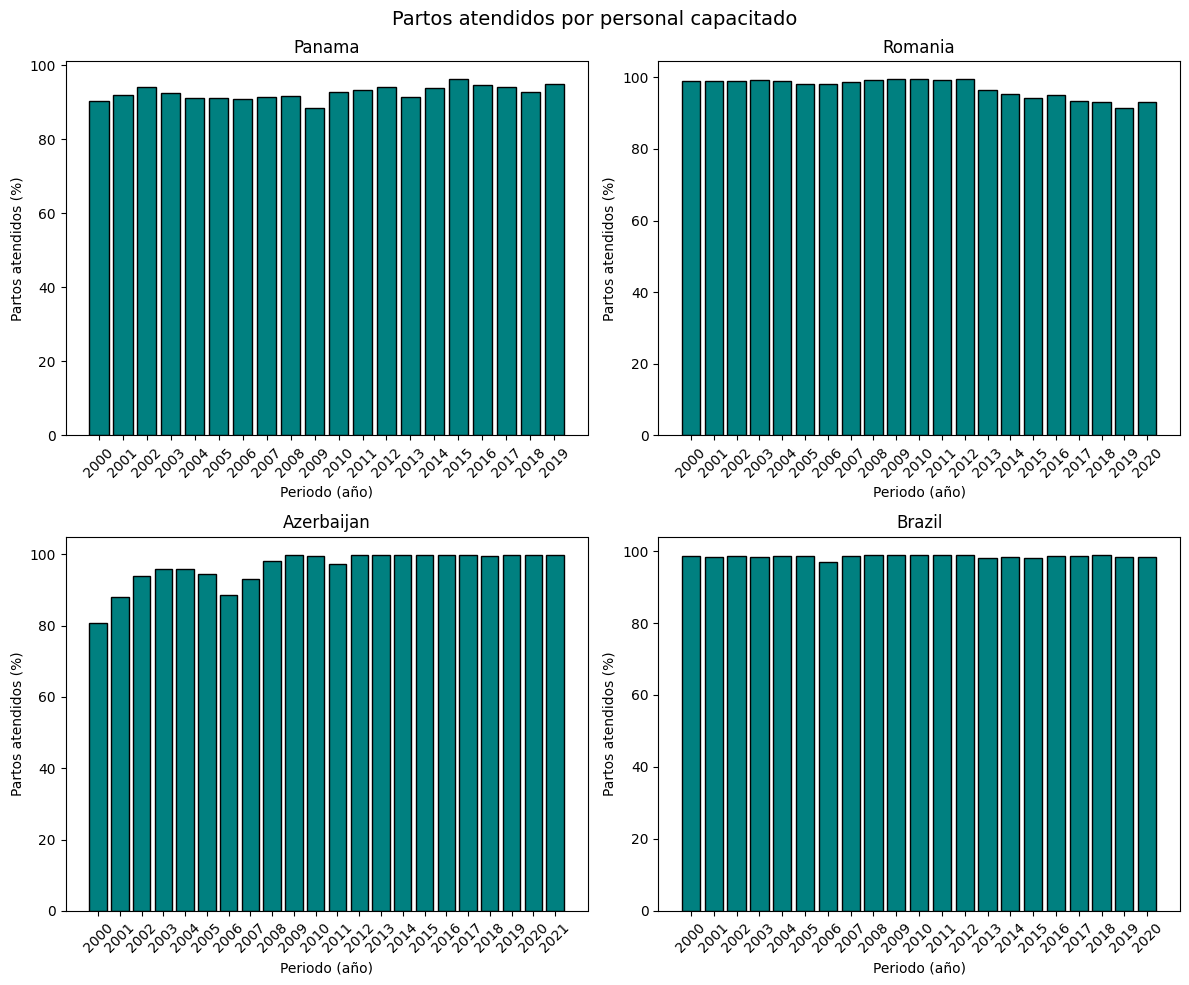

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, pais in zip(axes, paises_sel):
    sub = new_df[new_df["Pais"] == pais]
    ax.bar(sub["Periodo"].astype(str), sub["PartosAtendidos"], color="teal", edgecolor="black")
    ax.set_title(pais)
    ax.set_xlabel("Periodo (año)")
    ax.set_ylabel("Partos atendidos (%)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Partos atendidos por personal capacitado", fontsize=14)
fig.tight_layout()
plt.show()

## Con la selección anterior genere un gráfico de líneas para los países
### Asigne a cada país un símbolo y color. De igual manera cada punto debe estar enlazado con el anterior
### Muestre la leyenda del gráfico

En este gráfico *plt* tiende a delimitar el valor min y max del eje *Y*, por lo cual puede causar una interpretación errónea de los datos. 
Genere el gráfico con la configuración por defecto de *matplotlib* y luego copie su código y agrege el siguiente fragmento antes de la generación de los gráficos. **Comente sobre la diferencia de percepción en sus conclusiones**. Presente los resultados en las celdas **#10** y **#11** a continuación.

```python
ax = plt.gca()
ax.set_ylim([0, 120])
```

Este código obtiene el eje actual del gráfico y delimita para el eje seleccionado, los valores máximos y mínimos que se deben mostrar.

## **[10]** Presente el grafico de líneas solicitado sin usar ax.set_ylim

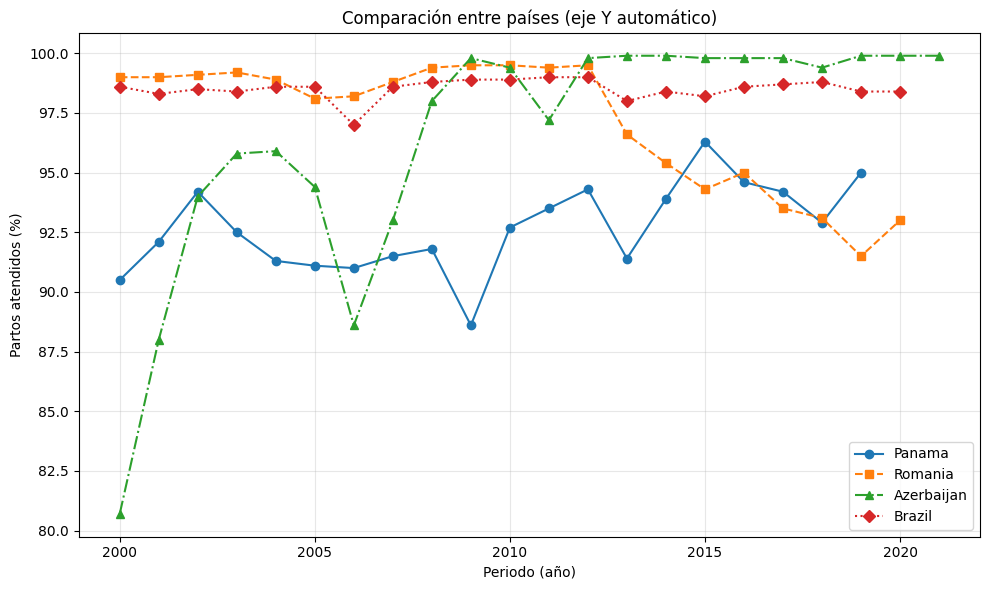

In [27]:
plt.figure(figsize=(10, 6))
estilos = [
    ("Panama", "o-", "tab:blue"),
    ("Romania", "s--", "tab:orange"),
    ("Azerbaijan", "^-.", "tab:green"),
    ("Brazil", "D:", "tab:red"),
]

for pais, fmt, color in estilos:
    sub = new_df[new_df["Pais"] == pais].sort_values("Periodo")
    plt.plot(sub["Periodo"], sub["PartosAtendidos"], fmt, color=color, label=pais, markersize=6)

plt.xlabel("Periodo (año)")
plt.ylabel("Partos atendidos (%)")
plt.title("Comparación entre países (eje Y automático)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **[11]** Presente el grafico de líneas solicitado usando ax.set_ylim

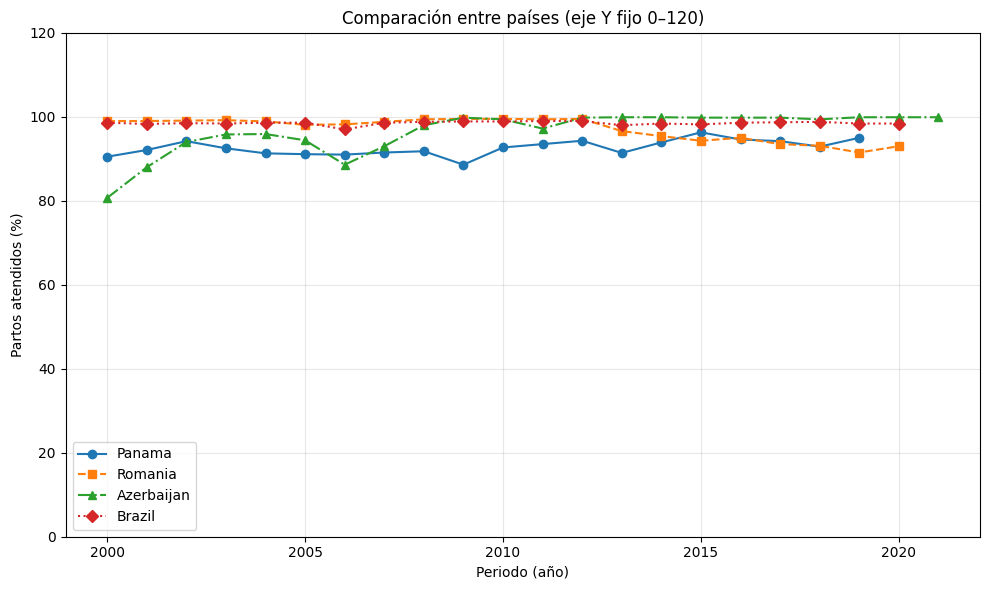

In [28]:
plt.figure(figsize=(10, 6))
estilos = [
    ("Panama", "o-", "tab:blue"),
    ("Romania", "s--", "tab:orange"),
    ("Azerbaijan", "^-.", "tab:green"),
    ("Brazil", "D:", "tab:red"),
]

for pais, fmt, color in estilos:
    sub = new_df[new_df["Pais"] == pais].sort_values("Periodo")
    plt.plot(sub["Periodo"], sub["PartosAtendidos"], fmt, color=color, label=pais, markersize=6)

ax = plt.gca()
ax.set_ylim([0, 120])

plt.xlabel("Periodo (año)")
plt.ylabel("Partos atendidos (%)")
plt.title("Comparación entre países (eje Y fijo 0–120)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **[12]** Usando la selección anterior, genere un *Scatter Plot*

Defina para este Scatterplot, que la propiedad *s*, sea el promedio de la tasa de partos atendidos por cada país. (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter).

El siguiente esquema de código permite el cálculo del promedio de la  **VariableParaMedia**  Agrupada por la columna **Atributo** del dataframe, este atributo generalmente es una variable categórica, por lo cual, la media se obtendra para cada categoría. Esto devuelve una estructura de tipo Serie, que se comporta similar a un arreglo, en esta para acceder a la media de un elemento se indica el nombre de la categoría que necesitamos utilizando los ```[]```.
```python
meanVal= df.groupby(['Atributo'])['VariableParaMedia'].mean()
meanCat1 = meanVal["Cat1"]
```


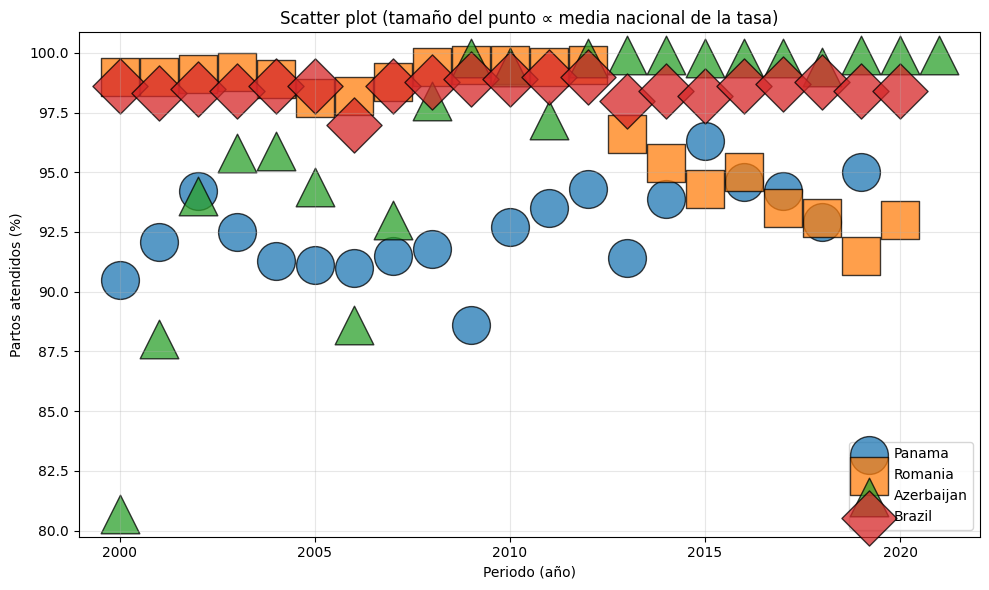

In [29]:
meanVal = new_df.groupby("Pais")["PartosAtendidos"].mean()

plt.figure(figsize=(10, 6))
markers = {"Panama": "o", "Romania": "s", "Azerbaijan": "^", "Brazil": "D"}
colors = {"Panama": "C0", "Romania": "C1", "Azerbaijan": "C2", "Brazil": "C3"}

for pais in paises_sel:
    sub = new_df[new_df["Pais"] == pais]
    plt.scatter(
        sub["Periodo"],
        sub["PartosAtendidos"],
        s=meanVal[pais] * 8,
        marker=markers[pais],
        c=colors[pais],
        label=pais,
        edgecolors="black",
        alpha=0.75,
    )

plt.xlabel("Periodo (año)")
plt.ylabel("Partos atendidos (%)")
plt.title("Scatter plot (tamaño del punto ∝ media nacional de la tasa)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Generación de un dataset que contenga solo los 25 países con mayor cantidad de datos

En este caso se utiliza la funcion *groupby* del dataframe para obtener la cantidad de valores que se tienen para cada país y al mismo tiempo la funcion *sort_values* para que este conteo se ordene de mayor a menor. 

Posteriormente se seleccionan de esta serie solo los países que tienen  $25$ o más datos/regitros en el dataset. Es decir países de los que se tienen información de la atención en al menos $25$ años. 

La variable *listaCortapaises* es una serie que contiene los países y el valor contado para cada país, en esta el índice(*index*) de la serie es el nombre del país. Para realizar nuestra selección se pide a la serie que dichos índices sean convertidos a una lista. 

Luego se selecciona del dataframe completo solo los países que se encuentran en *paisesSeleccion* usando el metodo *.isin()* del dataframe de Pandas. De esta manera nuestro *dfSelecion* solo contiene los registros de los 25 países con mayor cantidad de datos.

**Nota** : En este código *dfPartos* es nuestro dataset cargado a través de Pandas, por lo cual, debe colocar el nombre que usted asignó a esta variable.

In [30]:
# Se realiza el conteo 
# Se genera una serie de datos ordenada de acuerdo al pais con mas datos
conteo=dfPartos.groupby(['Pais'])['Periodo'].count().sort_values(ascending=False)

In [31]:
# Se seleccionan los primeros 25 paises
listaCortapaises = conteo[:25]  

In [32]:
paisesSeleccion = listaCortapaises.index.tolist()

In [33]:
dfSelecion = dfPartos[(dfPartos['Pais'].isin(paisesSeleccion))]

In [34]:
dfSelecion.groupby('Pais').count()

,Periodo,PartosAtendidos
Pais,,
Australia,21,21
Austria,21,21
Azerbaijan,22,22
Bahrain,20,20
Brazil,21,21
Brunei Darussalam,22,22
Canada,21,21
Chile,20,20
Ecuador,21,21


## **[13]** Usando **SubPlots** genere un gráfico que contenga las 25 gráficas con el índice por año de cada país.
### Para este gráfico coloque adecuadamente las etiquetas a cada eje y el título del gráfico general y de cada gráfica individual. 
### Guarde este gráfico en un formato PDF

**Nota:** Recuerde que puede usar un ciclo *for* para recorrer su matriz de gráficos y de esa manera trabajar cada gráfico de manera independiente.

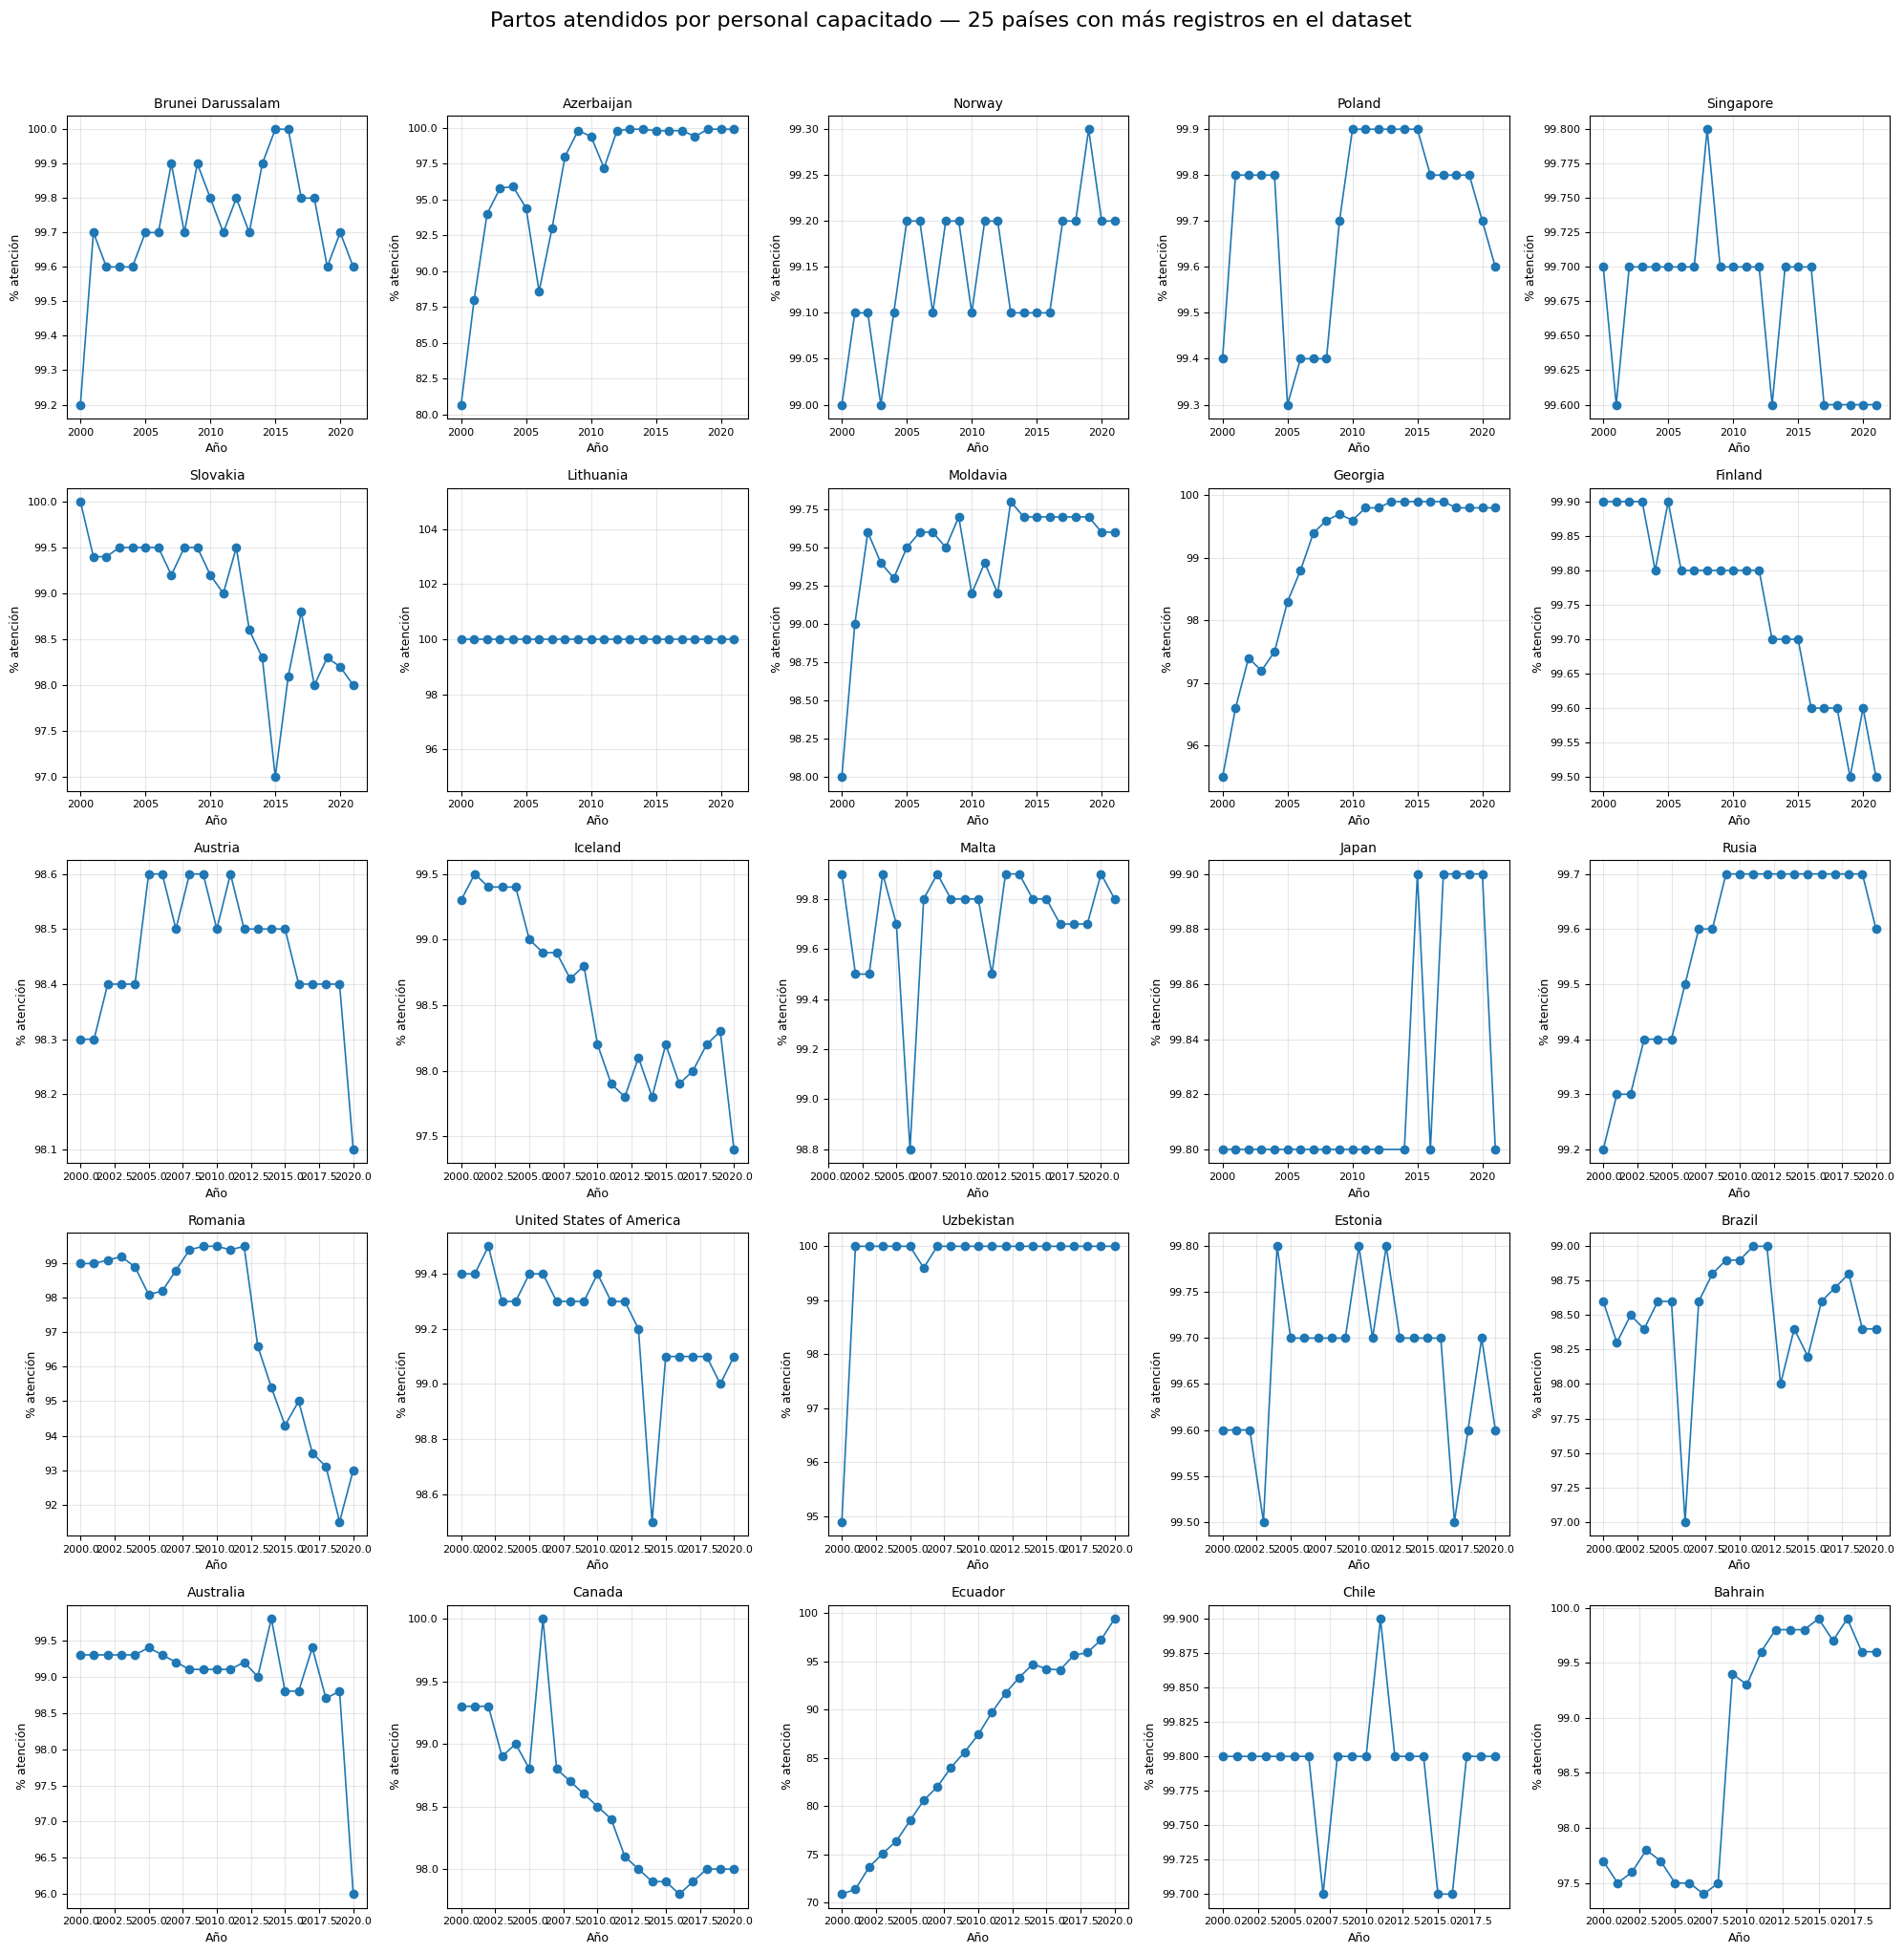

Figura guardada en: Lab3_PartosAtendidos_25Paises.pdf


In [35]:
paises_25 = listaCortapaises.index.tolist()

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()

for ax, pais in zip(axes, paises_25):
    sub = dfSelecion[dfSelecion["Pais"] == pais].sort_values("Periodo")
    ax.plot(sub["Periodo"], sub["PartosAtendidos"], marker="o", linewidth=1.2)
    ax.set_title(pais, fontsize=10)
    ax.set_xlabel("Año", fontsize=9)
    ax.set_ylabel("% atención", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Partos atendidos por personal capacitado — 25 países con más registros en el dataset",
    fontsize=16,
    y=1.02,
)
fig.tight_layout()

archivo_pdf = "Lab3_PartosAtendidos_25Paises.pdf"
plt.savefig(archivo_pdf, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {archivo_pdf}")

## **[14]** Conclusiones

1. **Datos y cobertura:** El archivo `AtencionPartos.csv` resume, por país y año, el porcentaje de partos atendidos por personal capacitado. La cantidad de observaciones por país es desigual; el análisis con los 25 países con más años registrados permite comparar series más completas.

2. **Panamá:** En el periodo disponible, la tasa se mantiene en un rango alto (aproximadamente entre el mínimo y el máximo calculados en el ejercicio [7]), con variación año a año visible en el gráfico de barras.

3. **Comparación regional (Panamá, Rumanía, Azerbaiyán, Brasil):** Las cuatro series muestran niveles elevados de cobertura en años recientes, pero con trayectorias distintas. Rumanía exhibe una tendencia a la baja en el tramo final del periodo, mientras que Azerbaiyán y Brasil permanecen muy cercanos al techo del indicador.

4. **Eje Y automático frente a `set_ylim([0, 120])`:** Con el eje Y automático, Matplotlib ajusta el rango al mínimo y máximo de los datos (aproximadamente entre 80 y 100 en este subconjunto). Eso **amplifica visualmente** las diferencias entre países y puede sugerir cambios más dramáticos de los que representan en puntos porcentuales absolutos. Al fijar el eje entre 0 y 120, las mismas curvas se ven **más “comprimidas”** y la percepción es de series más estables y similares entre sí. Por tanto, la escala del eje Y condiciona fuertemente la lectura del gráfico y debe elegirse según el mensaje que se quiera comunicar (detalle vs. contexto completo del 0–100%).

5. **Scatter plot:** Usar el área del punto (`s`) proporcional a la media nacional enfatiza países con promedios distintos a lo largo del tiempo y ayuda a relacionar dispersión año a año con el nivel típico del país.

6. **Subplots (25 países):** La matriz 5×5 resume de un vistazo la evolución por país; guardar la figura en PDF facilita entregarla o imprimirla sin perder resolución.


In [36]:
# Las conclusiones del laboratorio se redactaron en la celda markdown anterior ([14]).